# Machine Learning Models

In this project, 4 diferent machine learning models are going to be trained, tested and evaluated to see each one has  a better performance in predicting churn.
The choosen models are:
1. Logistic Regression
2. Random Forest 
3. XGBoost
4. Support Vector Machine (SVM)

The models will be evaluated using precision, recall, F1-score, and accuracy for both classes — with a focus on class 1 (churners), since missing a churner (false negative) is more costly than a false alarm.

Each model is trained in two phases: a baseline with default parameters, and a tuned version using RandomizedSearchCV optimised for F1. This allows a direct comparison of the gain from hyperparameter tuning.

To handle the class imbalance (~73% non-churn / ~27% churn), class_weight='balanced' is applied where available.

## Importe libraries and load dataset

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.load_data import load_data
from src.data.models import split_dataset, evaluate_model

df = load_data('../data/processed/telco_clean.csv')

X_train, X_test, y_train, y_test = split_dataset(df)

The processed dataset (telco_clean.csv) is loaded and split into 80% training / 20% test using stratified sampling to preserve the class distribution across both sets.

## Logistic Regression

## Random Forest

In [2]:
from src.models.random_forest import model_baseline, model_tuning

Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions. It is robust to overfitting and handles non-linear relationships well, making it a strong candidate for this type of tabular classification problem.

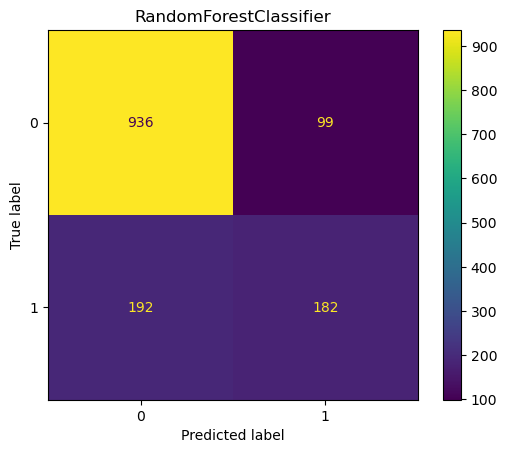

{'0': {'precision': 0.8297872340425532, 'recall': 0.9043478260869565, 'f1-score': 0.8654646324549237, 'support': 1035.0}, '1': {'precision': 0.6476868327402135, 'recall': 0.48663101604278075, 'f1-score': 0.5557251908396946, 'support': 374.0}, 'accuracy': 0.7934705464868701, 'macro avg': {'precision': 0.7387370333913834, 'recall': 0.6954894210648687, 'f1-score': 0.7105949116473091, 'support': 1409.0}, 'weighted avg': {'precision': 0.7814511445556299, 'recall': 0.7934705464868701, 'f1-score': 0.7832484854257572, 'support': 1409.0}}


In [3]:
baseline_model, report = model_baseline(X_train, X_test, y_train, y_test)

print(report)

The baseline Random Forest (default parameters, class_weight='balanced') achieves 78.8% overall accuracy, but this figure is misleading given the class imbalance (~73% non-churn / ~27% churn).

For the majority class (non-churners), performance is strong with an F1 of 0.86, which is expected as the model sees more examples of this class.

For the minority class (churners), performance is noticeably weaker — F1 of 0.56. Most critically, recall is only 0.52, meaning the model misses nearly half of all actual churners (false negatives). Since missing a churner is more costly than a false alarm in a business context, this is the key weakness of the baseline.

Despite class_weight='balanced' helping the model account for imbalance, the default hyperparameters are not sufficient to reliably identify churners. This motivates the tuning phase, which will optimise for F1 on class 1 using RandomizedSearchCV.

In [ ]:
best_model, report = model_tuning(X_train, X_test, y_train, y_test)

print(report)

## XGBoost

## Support Vector Machine